In [2]:
import pandas as pd
import numpy as np
df = pd.read_csv("../Data/raw/synthetic_it_support_tickets.csv")


In [3]:
df.head(10)

,ticket_id,created_at,customer_id,customer_segment,channel,product_area,issue_type,priority,status,sla_plan,initial_message,agent_first_reply,resolution_summary,resolution_time_hours,reopened,customer_sentiment,csat_score,has_attachment,platform,region
0,TCKT_000001,2024-01-31T05:14:27,CUST_00861,individual,email,data_export,account_access,low,resolved,standard,I cannot log in; the system says my password i...,Sorry to hear you're having trouble accessing ...,Reset account credentials and confirmed succes...,36.53,0,very_negative,1,0,android,EU
1,TCKT_000002,2024-10-20T06:15:49,CUST_00770,individual,in_app,billing,security_concern,medium,closed_no_action,standard,I noticed a suspicious login on my account.,We take security very seriously. Our team is r...,Ticket closed without further action after no ...,238.32,0,neutral,3,0,web,NaN
2,TCKT_000003,2024-06-18T21:35:54,CUST_02559,small_business,chat,api_integration,bug,low,in_progress,standard,The api integration feature is not saving my c...,Thanks for reporting this bug. We will look in...,NaN,NaN,0,neutral,3,0,android,MEA
3,TCKT_000004,2025-12-25T15:59:52,CUST_03557,education,chat,analytics_dashboard,account_access,medium,in_progress,standard,I cannot log in; the system says my password i...,Sorry to hear you're having trouble accessing ...,NaN,NaN,0,positive,5,1,android,LATAM
4,TCKT_000005,2023-08-27T16:08:33,CUST_09556,enterprise,phone_transcript,login_auth,billing_problem,low,resolved,gold,My invoice amount is incorrect compared to the...,Thanks for reaching out about the billing issu...,Adjusted the invoice and issued a refund where...,61.32,0,very_negative,2,0,web,NaN
5,TCKT_000006,2024-09-24T14:04:53,CUST_03844,education,email,mobile_app,performance,low,closed_no_action,gold,Queries in the mobile app module are timing out.,We understand performance issues can be frustr...,Ticket closed without further action after no ...,226.93,0,positive,5,0,ios,NaN
6,TCKT_000007,2024-11-01T16:14:51,CUST_01017,education,in_app,billing,security_concern,urgent,resolved,gold,I noticed a suspicious login on my account.,We take security very seriously. This has been...,"Investigated logs, mitigated the issue, and up...",4.36,0,negative,3,1,api_client,APAC
7,TCKT_000008,2024-11-07T06:43:26,CUST_00065,non_profit,phone_transcript,api_integration,billing_problem,low,resolved,standard,I downgraded my plan but I am still being bill...,Thanks for reaching out about the billing issu...,Adjusted the invoice and issued a refund where...,26.78,0,very_negative,0,0,web,NaN
8,TCKT_000009,2023-08-30T23:04:26,CUST_05893,small_business,phone_transcript,billing,billing_problem,high,resolved,platinum,I was charged twice for my subscription this m...,Thanks for reaching out about the billing issu...,Adjusted the invoice and issued a refund where...,20.55,0,negative,0,0,desktop_app,APAC
9,TCKT_000010,2023-04-26T19:33:56,CUST_02732,education,phone_transcript,login_auth,performance,medium,resolved,standard,Overall performance has degraded in the last f...,We understand performance issues can be frustr...,Optimized queries and increased resource alloc...,9.26,0,neutral,4,0,android,APAC


In [4]:
import matplotlib.pyplot as plt

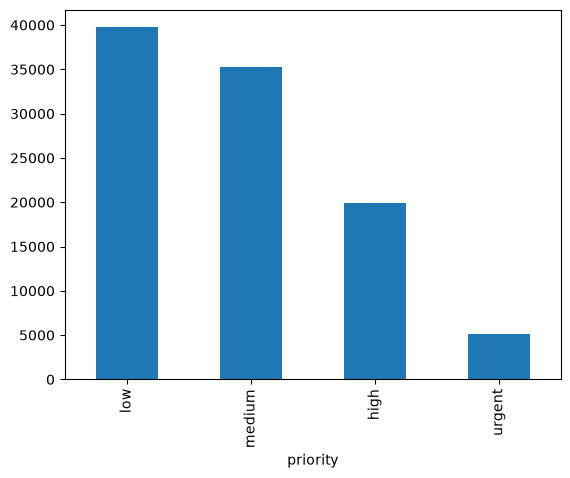

In [5]:
df["priority"].value_counts().plot(kind="bar")
plt.show()

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 20 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   ticket_id              100000 non-null  object 
 1   created_at             100000 non-null  object 
 2   customer_id            100000 non-null  object 
 3   customer_segment       100000 non-null  object 
 4   channel                100000 non-null  object 
 5   product_area           100000 non-null  object 
 6   issue_type             100000 non-null  object 
 7   priority               100000 non-null  object 
 8   status                 100000 non-null  object 
 9   sla_plan               100000 non-null  object 
 10  initial_message        100000 non-null  object 
 11  agent_first_reply      100000 non-null  object 
 12  resolution_summary     60113 non-null   object 
 13  resolution_time_hours  60113 non-null   float64
 14  reopened               100000 non-nul

In [7]:
missing_report = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing %": (df.isnull().sum() / len(df) * 100).round(2)
})

missing_report.sort_values("Missing %", ascending=False)

,Missing Values,Missing %
resolution_summary,39887,39.89
resolution_time_hours,39887,39.89
region,19997,20.00
ticket_id,0,0.00
customer_segment,0,0.00
customer_id,0,0.00
created_at,0,0.00
channel,0,0.00
status,0,0.00
product_area,0,0.00


In [8]:
pd.pivot_table(
    df,
    values="resolution_time_hours",
    index="priority",
    columns="customer_segment",
    aggfunc="mean"
)

customer_segment,education,enterprise,individual,non_profit,small_business
priority,,,,,
high,32.628732,31.535775,31.063055,30.844960,31.713056
low,54.888726,56.442308,54.614118,55.956807,56.120250
medium,42.826396,44.164430,42.663780,43.620931,43.138507
urgent,25.324861,29.692458,24.858845,25.883045,27.888433


In [9]:
np.where(df["resolution_time_hours"] <= 24, "Fast", "Slow")

array(['Slow', 'Slow', 'Slow', ..., 'Slow', 'Slow', 'Slow'],
      shape=(100000,), dtype='<U4')

In [10]:
df.describe()

,resolution_time_hours,reopened,csat_score,has_attachment
count,60113.000000,100000.000000,100000.000000,100000.000000
mean,45.013123,0.050450,2.241950,0.249520
std,49.202797,0.218873,1.771599,0.432737
min,0.110000,0.000000,0.000000,0.000000
25%,14.880000,0.000000,0.000000,0.000000
50%,29.910000,0.000000,2.000000,0.000000
75%,51.660000,0.000000,4.000000,0.000000
max,239.960000,1.000000,5.000000,1.000000


In [11]:
df.isnull().sum() / len(df)*100

ticket_id                 0.000
created_at                0.000
customer_id               0.000
customer_segment          0.000
channel                   0.000
product_area              0.000
issue_type                0.000
priority                  0.000
status                    0.000
sla_plan                  0.000
initial_message           0.000
agent_first_reply         0.000
resolution_summary       39.887
resolution_time_hours    39.887
reopened                  0.000
customer_sentiment        0.000
csat_score                0.000
has_attachment            0.000
platform                  0.000
region                   19.997
dtype: float64

In [12]:
df[df["resolution_time_hours"].isnull()]["status"].value_counts()

status
in_progress    19783
on_hold        10165
open            9939
Name: count, dtype: int64

In [13]:
df.columns

Index(['ticket_id', 'created_at', 'customer_id', 'customer_segment', 'channel',
       'product_area', 'issue_type', 'priority', 'status', 'sla_plan',
       'initial_message', 'agent_first_reply', 'resolution_summary',
       'resolution_time_hours', 'reopened', 'customer_sentiment', 'csat_score',
       'has_attachment', 'platform', 'region'],
      dtype='object')

In [14]:
df["region"].isnull().sum()

np.int64(19997)

In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
df["region"] = df["region"].fillna(df["region"].mode()[0])

In [17]:
df.dtypes

ticket_id                 object
created_at                object
customer_id               object
customer_segment          object
channel                   object
product_area              object
issue_type                object
priority                  object
status                    object
sla_plan                  object
initial_message           object
agent_first_reply         object
resolution_summary        object
resolution_time_hours    float64
reopened                   int64
customer_sentiment        object
csat_score                 int64
has_attachment             int64
platform                  object
region                    object
dtype: object

In [18]:
df["created_at"] = pd.to_datetime(df["created_at"])

In [19]:
df["created_at"].dt.year

0        2024
1        2024
2        2024
3        2025
4        2023
         ... 
99995    2023
99996    2025
99997    2025
99998    2022
99999    2022
Name: created_at, Length: 100000, dtype: int32

In [20]:
df["created_at"].dt.month

0         1
1        10
2         6
3        12
4         8
         ..
99995     5
99996     3
99997    11
99998     6
99999     2
Name: created_at, Length: 100000, dtype: int32

In [21]:
df["created_at"].dt.day

0        31
1        20
2        18
3        25
4        27
         ..
99995    16
99996    10
99997     7
99998    20
99999    27
Name: created_at, Length: 100000, dtype: int32

In [22]:
df["created_at"].dt.day_name()

0        Wednesday
1           Sunday
2          Tuesday
3         Thursday
4           Sunday
           ...    
99995      Tuesday
99996       Monday
99997       Friday
99998       Monday
99999       Sunday
Name: created_at, Length: 100000, dtype: object

In [23]:
df["created_at"].dt.hour

0         5
1         6
2        21
3        15
4        16
         ..
99995     6
99996     4
99997    19
99998    22
99999    14
Name: created_at, Length: 100000, dtype: int32

<Axes: xlabel='status'>

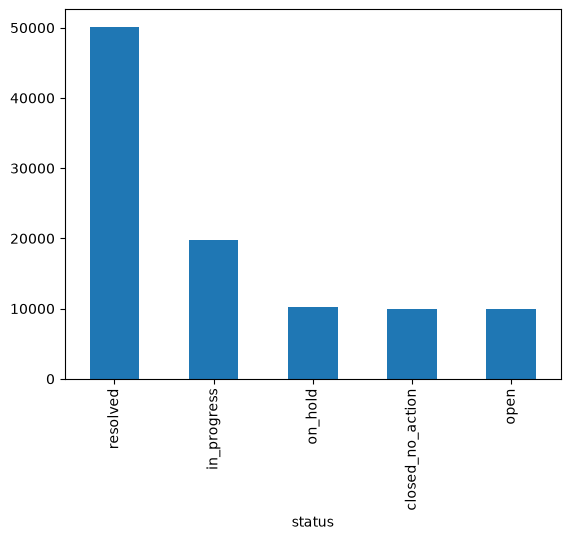

In [24]:
df["status"].value_counts().plot(kind="bar")

In [25]:
df["status"].unique()

array(['resolved', 'closed_no_action', 'in_progress', 'on_hold', 'open'],
      dtype=object)

In [26]:
df["created_at"].value_counts()

created_at
2023-12-28 02:25:35    2
2022-12-14 19:24:49    2
2025-01-25 22:49:40    2
2025-04-18 16:57:43    2
2025-10-23 07:27:06    2
                      ..
2023-07-24 01:23:00    1
2024-12-09 02:28:08    1
2023-06-07 19:51:14    1
2025-09-05 00:39:41    1
2024-11-01 16:14:51    1
Name: count, Length: 99959, dtype: int64

In [31]:
df.columns

Index(['ticket_id', 'created_at', 'customer_id', 'customer_segment', 'channel',
       'product_area', 'issue_type', 'priority', 'status', 'sla_plan',
       'initial_message', 'agent_first_reply', 'resolution_summary',
       'resolution_time_hours', 'reopened', 'customer_sentiment', 'csat_score',
       'has_attachment', 'platform', 'region'],
      dtype='object')

In [38]:
df["customer_sentiment"].unique()

array(['very_negative', 'neutral', 'positive', 'negative',
       'very_positive'], dtype=object)

<Axes: xlabel='customer_sentiment'>

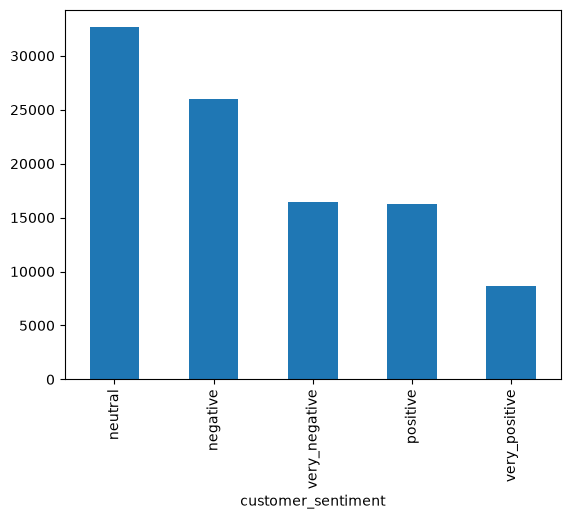

In [40]:
df["customer_sentiment"].value_counts().plot(kind="bar")

<Axes: xlabel='created_at'>

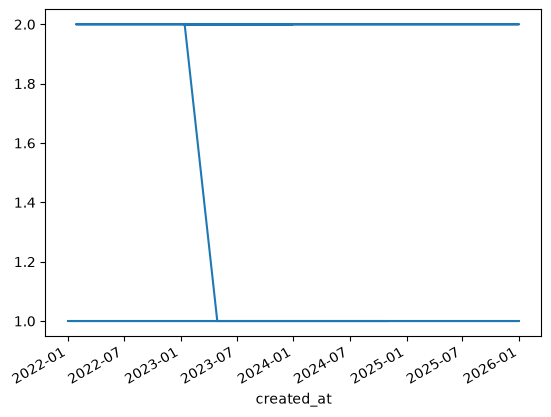

In [43]:
df["created_at"].value_counts().plot(kind="line")

In [46]:
df["status"].value_counts()

status
resolved            50131
in_progress         19783
on_hold             10165
closed_no_action     9982
open                 9939
Name: count, dtype: int64

In [53]:
categorical_columns = df.select_dtypes(include="object").columns

In [54]:
for col in categorical_columns:
    print("=" * 50)
    print(f"Column: {col}")
    print(df[col].value_counts())
    print("\n")

Column: ticket_id
ticket_id
TCKT_099984    1
TCKT_099983    1
TCKT_099982    1
TCKT_099981    1
TCKT_099980    1
              ..
TCKT_000005    1
TCKT_000004    1
TCKT_000003    1
TCKT_000002    1
TCKT_000001    1
Name: count, Length: 100000, dtype: int64


Column: customer_id
customer_id
CUST_07153    26
CUST_05691    23
CUST_08898    23
CUST_06800    22
CUST_04334    22
              ..
CUST_09288     1
CUST_06181     1
CUST_00389     1
CUST_02305     1
CUST_04251     1
Name: count, Length: 9999, dtype: int64


Column: customer_segment
customer_segment
small_business    20203
individual        20033
enterprise        20030
education         19958
non_profit        19776
Name: count, dtype: int64


Column: channel
channel
phone_transcript    20133
email               20088
in_app              19982
web_form            19965
chat                19832
Name: count, dtype: int64


Column: product_area
product_area
mobile_app             14432
login_auth             14381
api_integration 

In [55]:
df.nunique()

ticket_id                100000
created_at                99959
customer_id                9999
customer_segment              5
channel                       5
product_area                  7
issue_type                    8
priority                      4
status                        5
sla_plan                      3
initial_message              96
agent_first_reply            32
resolution_summary            9
resolution_time_hours     13303
reopened                      2
customer_sentiment            5
csat_score                    6
has_attachment                2
platform                      5
region                        4
dtype: int64

In [56]:
categorical_columns = [
    "customer_segment",
    "channel",
    "product_area",
    "issue_type",
    "priority",
    "status",
    "sla_plan",
    "customer_sentiment",
    "platform",
    "region"
]

In [61]:
for col in categorical_columns:
    print("=" * 50)
    print(f"\n{col}")
    print("=" * 50)
    print(df[col].unique())


customer_segment
['individual' 'small_business' 'education' 'enterprise' 'non_profit']

channel
['email' 'in_app' 'chat' 'phone_transcript' 'web_form']

product_area
['data_export' 'billing' 'api_integration' 'analytics_dashboard'
 'login_auth' 'mobile_app' 'notifications']

issue_type
['account_access' 'security_concern' 'bug' 'billing_problem' 'performance'
 'feature_request' 'how_to' 'other']

priority
['low' 'medium' 'urgent' 'high']

status
['resolved' 'closed_no_action' 'in_progress' 'on_hold' 'open']

sla_plan
['standard' 'gold' 'platinum']

customer_sentiment
['very_negative' 'neutral' 'positive' 'negative' 'very_positive']

platform
['android' 'web' 'ios' 'api_client' 'desktop_app']

region
['EU' 'MEA' 'LATAM' 'APAC']
